# 03 — Entrenamiento ABSA (BERT multilingual + TextCNN) sobre gold set v3

**Bitácora metodológica reproducible.** Este notebook entrena y evalúa el módulo ABSA
de la Fase 2 sobre el **gold set v3** (ampliado priorizando la clase negativa) y deja
registro visible de: qué datos se usaron, qué configuración se entrenó, qué resultó y
si cumple la especificación.

- **Especificación:** [`specs/modulo-absa-fase2.md`](../specs/modulo-absa-fase2.md)
- **Partición:** `outputs/reports/split_report_gold_v3.md`

**Objetivo (criterio de éxito):** F1-macro ≥ 0.70 en test, con mínimos por clase
(negativo F1 ≥ 0.60 y recall ≥ 0.60; neutro F1 ≥ 0.60). Si no se alcanza, se entrega
como *versión base defendible* con comparación, análisis de errores y límites del gold.

### Cómo ejecutarlo
1. Crear entorno e instalar dependencias: `pip install -r requirements.txt`
   (instala PyTorch acorde a tu CUDA primero — ver `requirements.txt`).
2. Ejecutar todas las celdas en orden (Kernel → Restart & Run All).
3. **El notebook ENTRENA** (3 semillas). En GPU potente toma decenas de minutos; en
   GPU modesta, varias horas. Ajusta `BATCH` y `USE_GRADIENT_CHECKPOINTING` abajo.

In [1]:
from pathlib import Path
import json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             confusion_matrix, classification_report)

pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)

# Raiz del proyecto (el notebook vive en notebooks/)
BASE = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATA, REP, VIS = BASE / "data", BASE / "outputs" / "reports", BASE / "outputs" / "visualizations"
for d in (REP, VIS): d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
LABELS = ["negativo", "neutro", "positivo"]; L2I = {l: i for i, l in enumerate(LABELS)}; I2L = {i: l for l, i in L2I.items()}

# ---------------- Config de entrenamiento ----------------
MODEL_NAME = "bert-base-multilingual-cased"
MAX_LEN, BATCH, EPOCHS = 256, 8, 12
LR, WEIGHT_DECAY, WARMUP_RATIO, PATIENCE, DROPOUT = 2e-5, 0.10, 0.10, 3, 0.40
CNN_FILTERS, CNN_KERNELS = 128, (2, 3, 4)
SEEDS = [42, 7, 123]            # >=3 semillas (requisito de la spec)
FOCAL_GAMMA, NEG_BOOST = 2.0, 1.5
# GPU con poca VRAM (<6GB): pon True y baja BATCH a 4. GPU potente: deja False y sube BATCH.
USE_GRADIENT_CHECKPOINTING = False
# Umbrales de la spec
TH_MACRO, TH_NEG_F1, TH_NEG_REC, TH_NEU_F1 = 0.70, 0.60, 0.60, 0.60

print("BASE:", BASE, "| DEVICE:", DEVICE, "| AMP:", USE_AMP)
print("Config:", dict(model=MODEL_NAME, max_len=MAX_LEN, batch=BATCH, epochs=EPOCHS, lr=LR,
                      seeds=SEEDS, focal_gamma=FOCAL_GAMMA, neg_boost=NEG_BOOST,
                      grad_checkpoint=USE_GRADIENT_CHECKPOINTING))

BASE: c:\Users\danie\Documents\Proyectos\ABSA_Turismo_Fase2_V3 | DEVICE: cuda | AMP: True
Config: {'model': 'bert-base-multilingual-cased', 'max_len': 256, 'batch': 8, 'epochs': 12, 'lr': 2e-05, 'seeds': [42, 7, 123], 'focal_gamma': 2.0, 'neg_boost': 1.5, 'grad_checkpoint': False}


## 1. Carga del gold set v3 y de los splits

Gold v3 (3.562 ítems aspecto-texto-label, consenso de 3 anotadores, κ≈0.89) y las
particiones `train/val/test_gold_v3.csv` (estratificadas por polaridad, agrupadas por
`review_uid`).

In [2]:
gold  = pd.read_csv(DATA / "gold_set_v3.csv", encoding="utf-8-sig")
train = pd.read_csv(DATA / "train_gold_v3.csv", encoding="utf-8-sig")
val   = pd.read_csv(DATA / "val_gold_v3.csv", encoding="utf-8-sig")
test  = pd.read_csv(DATA / "test_gold_v3.csv", encoding="utf-8-sig")
for d in (gold, train, val, test):
    d["label"] = d["label"].astype(str).str.lower().str.strip()
    if "input_modelo" not in d.columns or d["input_modelo"].isna().any():
        d["input_modelo"] = "aspecto: " + d["aspecto"].astype(str) + " reseña: " + d["text_clean"].astype(str)

print(f"gold v3 : {len(gold):5d} ítems | {gold['review_uid'].nunique()} reseñas únicas")
for nm, d in [("train", train), ("val", val), ("test", test)]:
    print(f"{nm:5s}   : {len(d):5d} ({len(d)/len(gold)*100:.1f}%)")
train.head(3)

gold v3 :  3562 ítems | 1564 reseñas únicas
train   :  2498 (70.1%)
val     :   532 (14.9%)
test    :   532 (14.9%)


,annotation_id,review_uid,destination,language_review,aspecto,text_clean,input_modelo,label,origen,split
0,gm_e9e965e3923ca842__atractivos,gm_e9e965e3923ca842,Centro Histórico de Lima,en,atractivos,The main center of power in Peru but also a hi...,aspecto: atractivos reseña: The main center of...,positivo,consenso_v2,train
1,gm_f8a6c506087755b5__atractivos,gm_f8a6c506087755b5,Líneas y Geoglifos de Nasca y Palpa,es,atractivos,Hermoso lugar que puedes visitar y disfrutar d...,aspecto: atractivos reseña: Hermoso lugar que ...,positivo,consenso_v2,train
2,gm_f8a6c506087755b5__accesibilidad,gm_f8a6c506087755b5,Líneas y Geoglifos de Nasca y Palpa,es,accesibilidad,Hermoso lugar que puedes visitar y disfrutar d...,aspecto: accesibilidad reseña: Hermoso lugar q...,positivo,consenso_v2,train


## 2. Verificación de no fuga por `review_uid`

Ninguna reseña puede aparecer en más de un split.

In [3]:
s_tr, s_va, s_te = set(train.review_uid), set(val.review_uid), set(test.review_uid)
fuga = {"train∩val": len(s_tr & s_va), "train∩test": len(s_tr & s_te), "val∩test": len(s_va & s_te)}
print("Solapamientos de review_uid:", fuga)
assert sum(fuga.values()) == 0, "FUGA detectada entre splits"
print("✅ Sin fuga: cada reseña aparece en un solo split.")

Solapamientos de review_uid: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
✅ Sin fuga: cada reseña aparece en un solo split.


## 3. Distribución por split (polaridad, aspecto, destino, idioma)

Polaridad por split (conteo):


split,train,val,test
label,,,
negativo,545,117,116
neutro,809,173,173
positivo,1144,242,243


Polaridad por split (%):


split,train,val,test
label,,,
negativo,21.8,22.0,21.8
neutro,32.4,32.5,32.5
positivo,45.8,45.5,45.7


Aspecto por split:


split,train,val,test
aspecto,,,
accesibilidad,321,65,55
aforo_multitudes,198,37,51
alojamiento,65,19,21
atencion_servicio,387,79,82
atractivos,688,147,145
clima,79,25,19
costos,314,56,63
gastronomia,74,19,12
limpieza,199,55,44


Idioma por split:


split,train,val,test
language_review,,,
en,1105,229,230
es,1393,303,302


Destino por split:


split,train,val,test
destination,,,
Centro Histórico de Lima,277,40,59
Circuito Mágico del Agua,275,91,66
Ciudadela de Kuélap,205,71,20
Líneas y Geoglifos de Nasca y Palpa,173,42,30
Monasterio de Santa Catalina,253,32,48
Museo Tumbas Reales del Señor de Sipán,161,20,63
Museo de Sitio Huaca Pucllana,312,51,82
Reserva Nacional de Paracas,219,57,27
Santuario Histórico de Machu Picchu,459,77,92


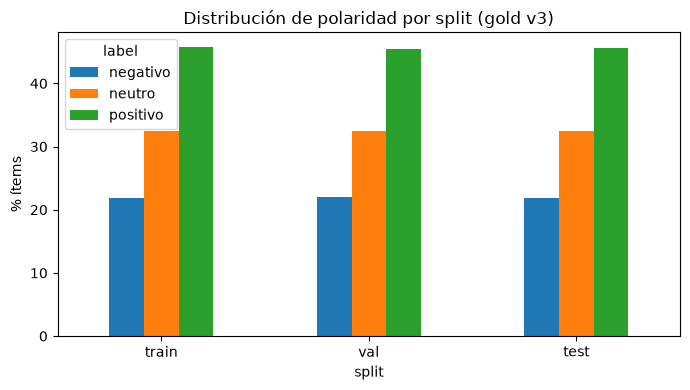

In [4]:
alld = pd.concat([train.assign(split="train"), val.assign(split="val"), test.assign(split="test")])
def tabla(col):
    # groupby+size evita el conflicto de usar la misma columna como index y values
    t = alld.groupby([col, "split"]).size().unstack("split", fill_value=0)
    return t.reindex(columns=["train", "val", "test"], fill_value=0)

print("Polaridad por split (conteo):"); display(tabla("label"))
print("Polaridad por split (%):");      display((tabla("label") / tabla("label").sum() * 100).round(1))
print("Aspecto por split:");            display(tabla("aspecto"))
if "language_review" in train: print("Idioma por split:"); display(tabla("language_review"))
if "destination" in train:     print("Destino por split:"); display(tabla("destination"))

prop = (tabla("label") / tabla("label").sum() * 100)[["train", "val", "test"]]
ax = prop.T.plot(kind="bar", figsize=(7, 4)); ax.set_ylabel("% ítems")
ax.set_title("Distribución de polaridad por split (gold v3)"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 4. Modelo: BERT multilingual + TextCNN

Encoder Transformer multilingüe → convoluciones 1D (kernels 2/3/4) + max-pooling →
clasificador lineal de 3 clases. La ablación previa mostró que cambiar el encoder no es
la palanca; se conserva esta arquitectura base y se ataca la señal de la clase negativa.

In [5]:
class ABSADataset(Dataset):
    def __init__(self, texts, labels, tok):
        self.t = list(texts); self.l = list(labels); self.tok = tok
    def __len__(self): return len(self.t)
    def __getitem__(self, i):
        e = self.tok(str(self.t[i]), add_special_tokens=True, max_length=MAX_LEN, padding="max_length",
                     truncation=True, return_attention_mask=True, return_tensors="pt")
        return {"input_ids": e["input_ids"].squeeze(0), "attention_mask": e["attention_mask"].squeeze(0),
                "labels": torch.tensor(L2I[self.l[i]], dtype=torch.long)}

class BERTTextCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        if USE_GRADIENT_CHECKPOINTING:
            self.bert.config.use_cache = False
            self.bert.gradient_checkpointing_enable()
        h = self.bert.config.hidden_size
        self.convs = nn.ModuleList([nn.Conv1d(h, CNN_FILTERS, k) for k in CNN_KERNELS])
        self.drop = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(CNN_FILTERS * len(CNN_KERNELS), 3)
    def forward(self, ids, mask):
        x = self.bert(input_ids=ids, attention_mask=mask).last_hidden_state.transpose(1, 2)
        pooled = [torch.max(torch.relu(c(x)), dim=2).values for c in self.convs]
        return self.fc(self.drop(torch.cat(pooled, dim=1)))

print("Modelo definido:", BERTTextCNN.__name__)

Modelo definido: BERTTextCNN


## 5. Configuración enfocada a la clase negativa

La clase negativa es el cuello de botella. Se combinan **class weights** inversos a la
frecuencia con **refuerzo extra a negativa** (`NEG_BOOST=1.5`) y **Focal Loss**
(`gamma=2.0`), que enfoca los ejemplos difíciles (típicamente negativos confundidos con
neutro). Abajo se muestran los pesos reales por clase.

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, weight, gamma): super().__init__(); self.w=weight; self.g=gamma
    def forward(self, logits, y):
        ce = nn.functional.cross_entropy(logits, y, weight=self.w, reduction="none")
        return (((1 - torch.exp(-ce)) ** self.g) * ce).mean()

def class_weights(labels):
    c = pd.Series(labels).value_counts().reindex(LABELS, fill_value=0); tot = c.sum()
    w = [tot / (len(LABELS) * c[l]) if c[l] > 0 else 0.0 for l in LABELS]
    w[L2I["negativo"]] *= NEG_BOOST
    return torch.tensor(w, dtype=torch.float).to(DEVICE)

_w = class_weights(train["label"])
print("Pesos por clase (con refuerzo a negativa):")
for l in LABELS: print(f"  {l:9s}: {float(_w[L2I[l]]):.3f}")
print(f"Focal gamma = {FOCAL_GAMMA} | NEG_BOOST = {NEG_BOOST}")

Pesos por clase (con refuerzo a negativa):
  negativo : 2.292
  neutro   : 1.029
  positivo : 0.728
Focal gamma = 2.0 | NEG_BOOST = 1.5


## 6. Entrenamiento con ≥ 3 semillas

Cada semilla: entrenamiento con early stopping por F1-macro en validación; se guarda el
mejor checkpoint. Al final, **ensemble** por promedio de probabilidades.

In [7]:
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

def metrics(trues, preds):
    pr, rc, f1, _ = precision_recall_fscore_support(trues, preds, labels=LABELS, average=None, zero_division=0)
    _, _, mf1, _ = precision_recall_fscore_support(trues, preds, labels=LABELS, average="macro", zero_division=0)
    out = {"f1_macro": mf1, "accuracy": accuracy_score(trues, preds)}
    for i, l in enumerate(LABELS): out[f"f1_{l}"] = f1[i]; out[f"recall_{l}"] = rc[i]
    return out

def predict(model, loader):
    model.eval(); P, T = [], []
    with torch.no_grad():
        for b in loader:
            with torch.autocast("cuda", enabled=USE_AMP):
                lo = model(b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE))
            P.append(torch.softmax(lo.float(), 1).cpu().numpy()); T += [I2L[y] for y in b["labels"].numpy()]
    return np.concatenate(P), T

def train_one(seed):
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    tl = DataLoader(ABSADataset(train["input_modelo"], train["label"], tok), batch_size=BATCH, shuffle=True)
    vl = DataLoader(ABSADataset(val["input_modelo"], val["label"], tok), batch_size=BATCH)
    el = DataLoader(ABSADataset(test["input_modelo"], test["label"], tok), batch_size=BATCH)
    model = BERTTextCNN().to(DEVICE)
    loss_fn = FocalLoss(class_weights(train["label"]), FOCAL_GAMMA)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    tot = len(tl) * EPOCHS
    sch = get_linear_schedule_with_warmup(opt, int(tot * WARMUP_RATIO), tot)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    best, best_state, pat = -1, None, 0
    for ep in range(1, EPOCHS + 1):
        model.train()
        for b in tl:
            opt.zero_grad()
            with torch.autocast("cuda", enabled=USE_AMP):
                loss = loss_fn(model(b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE)), b["labels"].to(DEVICE))
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(opt); scaler.update(); sch.step()
        vp, vt = predict(model, vl); vf = metrics(vt, [I2L[i] for i in vp.argmax(1)])["f1_macro"]
        print(f"    seed {seed} epoch {ep:2d}/{EPOCHS}  val_f1_macro={vf:.3f}")
        if vf > best: best, best_state, pat = vf, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            pat += 1
            if pat >= PATIENCE: print("    early stopping"); break
    if best_state: model.load_state_dict(best_state)
    tp, tt = predict(model, el); del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return tp, tt

t0 = time.time()
rows, probs, test_trues = [], [], None
for seed in SEEDS:
    print(f"=== Semilla {seed} ===")
    p, tt = train_one(seed); test_trues = tt; probs.append(p)
    m = metrics(tt, [I2L[i] for i in p.argmax(1)])
    rows.append({"seed": seed, **{k: round(v, 4) for k, v in m.items()}})
    print(f"  -> f1_macro={m['f1_macro']:.3f} f1_neg={m['f1_negativo']:.3f} rec_neg={m['recall_negativo']:.3f} f1_neu={m['f1_neutro']:.3f}")

det = pd.DataFrame(rows)
ens_probs = np.mean(probs, axis=0)
ens_preds = [I2L[i] for i in ens_probs.argmax(1)]
ens_metrics = metrics(test_trues, ens_preds)
det.to_csv(REP / "resultados_bert_textcnn_v3.csv", index=False, encoding="utf-8-sig")
print(f"\nEntrenamiento completo en {(time.time()-t0)/60:.1f} min")

=== Semilla 42 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\danie\Documents\Proyectos\ABSA_Turismo_Fase2_V3\absa_env\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in t

    seed 42 epoch  1/12  val_f1_macro=0.410
    seed 42 epoch  2/12  val_f1_macro=0.606
    seed 42 epoch  3/12  val_f1_macro=0.601
    seed 42 epoch  4/12  val_f1_macro=0.567
    seed 42 epoch  5/12  val_f1_macro=0.594
    early stopping
  -> f1_macro=0.583 f1_neg=0.478 rec_neg=0.569 f1_neu=0.574
=== Semilla 7 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\danie\Documents\Proyectos\ABSA_Turismo_Fase2_V3\absa_env\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in t

    seed 7 epoch  1/12  val_f1_macro=0.484
    seed 7 epoch  2/12  val_f1_macro=0.589
    seed 7 epoch  3/12  val_f1_macro=0.508
    seed 7 epoch  4/12  val_f1_macro=0.567
    seed 7 epoch  5/12  val_f1_macro=0.601
    seed 7 epoch  6/12  val_f1_macro=0.629
    seed 7 epoch  7/12  val_f1_macro=0.642
    seed 7 epoch  8/12  val_f1_macro=0.676
    seed 7 epoch  9/12  val_f1_macro=0.674
    seed 7 epoch 10/12  val_f1_macro=0.656
    seed 7 epoch 11/12  val_f1_macro=0.663
    early stopping
  -> f1_macro=0.666 f1_neg=0.578 rec_neg=0.578 f1_neu=0.667
=== Semilla 123 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\danie\Documents\Proyectos\ABSA_Turismo_Fase2_V3\absa_env\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in t

    seed 123 epoch  1/12  val_f1_macro=0.553
    seed 123 epoch  2/12  val_f1_macro=0.544
    seed 123 epoch  3/12  val_f1_macro=0.578
    seed 123 epoch  4/12  val_f1_macro=0.589
    seed 123 epoch  5/12  val_f1_macro=0.612
    seed 123 epoch  6/12  val_f1_macro=0.609
    seed 123 epoch  7/12  val_f1_macro=0.625
    seed 123 epoch  8/12  val_f1_macro=0.635
    seed 123 epoch  9/12  val_f1_macro=0.648
    seed 123 epoch 10/12  val_f1_macro=0.640
    seed 123 epoch 11/12  val_f1_macro=0.656
    seed 123 epoch 12/12  val_f1_macro=0.659
  -> f1_macro=0.651 f1_neg=0.568 rec_neg=0.595 f1_neu=0.626

Entrenamiento completo en 29.0 min


## 7. Resultados por semilla

In [8]:
display(det)

,seed,f1_macro,accuracy,f1_negativo,recall_negativo,f1_neutro,recall_neutro,f1_positivo,recall_positivo
0,42,0.5829,0.5977,0.4783,0.5690,0.5738,0.6069,0.6967,0.6049
1,7,0.6657,0.6823,0.5776,0.5776,0.6667,0.7688,0.7529,0.6708
2,123,0.6513,0.6711,0.5679,0.5948,0.6257,0.6474,0.7603,0.7243


## 8. Promedio ± desviación estándar

La selección no se basa en la mejor corrida sino en el promedio. Std del F1-macro > 0.03
indica inestabilidad.

In [9]:
cols = [c for c in det.columns if c != "seed"]
agg = pd.DataFrame({"media": det[cols].mean().round(4), "desv_std": det[cols].std().round(4)})
display(agg)
std_macro = det["f1_macro"].std()
print(f"Std F1-macro = {std_macro:.4f} -> {'ESTABLE' if std_macro <= 0.03 else 'INESTABLE (>0.03)'}")

,media,desv_std
f1_macro,0.6333,0.0442
accuracy,0.6504,0.0460
f1_negativo,0.5413,0.0547
recall_negativo,0.5805,0.0131
f1_neutro,0.6221,0.0466
recall_neutro,0.6744,0.0843
f1_positivo,0.7366,0.0348
recall_positivo,0.6667,0.0598


Std F1-macro = 0.0442 -> INESTABLE (>0.03)


## 9. Métricas obligatorias (ensemble): F1-macro, por clase, recall negativo, matriz de confusión, por aspecto

Classification report (ensemble):


,precision,recall,f1-score,support
negativo,0.568,0.647,0.605,116.00
neutro,0.610,0.705,0.654,173.00
positivo,0.850,0.700,0.767,243.00
accuracy,0.690,0.690,0.690,0.69
macro avg,0.676,0.684,0.675,532.00
weighted avg,0.711,0.690,0.695,532.00


F1-macro por aspecto (peor a mejor):


,aspecto,soporte,f1_macro
2,alojamiento,21,0.2883
5,clima,19,0.4026
1,aforo_multitudes,51,0.4081
8,limpieza,44,0.4348
7,gastronomia,12,0.4474
4,atractivos,145,0.5296
3,atencion_servicio,82,0.5458
0,accesibilidad,55,0.5511
6,costos,63,0.5637
9,seguridad,40,0.5811


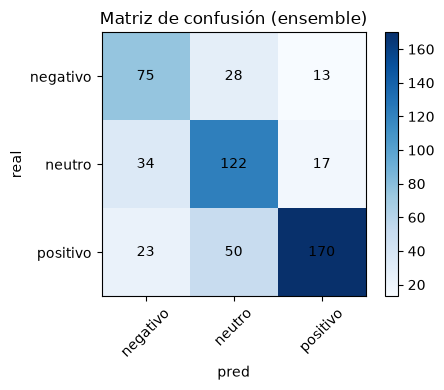

In [10]:
print("Classification report (ensemble):")
cr = pd.DataFrame(classification_report(test_trues, ens_preds, labels=LABELS, output_dict=True, zero_division=0)).T
display(cr.round(3)); cr.to_csv(REP / "classification_report_v3.csv", encoding="utf-8-sig")

# Por aspecto
ta = test.copy(); ta["pred"] = ens_preds; filas = []
for asp, g in ta.groupby("aspecto"):
    _, _, f1, _ = precision_recall_fscore_support(g["label"], g["pred"], labels=LABELS, average="macro", zero_division=0)
    filas.append({"aspecto": asp, "soporte": len(g), "f1_macro": round(f1, 4)})
por_asp = pd.DataFrame(filas).sort_values("f1_macro"); por_asp.to_csv(REP / "por_aspecto_v3.csv", index=False, encoding="utf-8-sig")
print("F1-macro por aspecto (peor a mejor):"); display(por_asp)

cm = confusion_matrix(test_trues, ens_preds, labels=LABELS)
plt.figure(figsize=(5, 4)); plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.xticks(range(3), LABELS, rotation=45); plt.yticks(range(3), LABELS)
for i in range(3):
    for j in range(3): plt.text(j, i, cm[i, j], ha="center", va="center")
plt.title("Matriz de confusión (ensemble)"); plt.ylabel("real"); plt.xlabel("pred")
plt.tight_layout(); plt.savefig(VIS / "matriz_confusion_v3.png", dpi=180); plt.show()

## 10. Veredicto automático contra la especificación

- **Éxito técnico:** F1-macro ≥ 0.70 **y** negativo F1 ≥ 0.60 **y** recall negativo ≥ 0.60 **y** neutro F1 ≥ 0.60.
- **Versión base defendible:** si no, pero con comparación, análisis de errores y límites del gold.

In [11]:
checks = {
    "F1-macro ≥ 0.70":        (ens_metrics["f1_macro"], TH_MACRO),
    "Negativo F1 ≥ 0.60":     (ens_metrics["f1_negativo"], TH_NEG_F1),
    "Recall negativo ≥ 0.60": (ens_metrics["recall_negativo"], TH_NEG_REC),
    "Neutro F1 ≥ 0.60":       (ens_metrics["f1_neutro"], TH_NEU_F1),
}
print("=== Veredicto contra la spec (ensemble) ===")
todos = True
for k, (v, th) in checks.items():
    ok = v >= th; todos &= ok
    print(f"  [{'PASA' if ok else 'FALLA'}] {k:24s} -> {v:.3f}")
estable = det["f1_macro"].std() <= 0.03
print(f"  [{'OK' if estable else 'X'}] Estabilidad std F1-macro ≤ 0.03 -> {det['f1_macro'].std():.4f}")
VEREDICTO = "ÉXITO TÉCNICO" if todos else "VERSIÓN BASE DEFENDIBLE"
print("\nRESULTADO:", "✅ ÉXITO TÉCNICO (cumple la spec)" if todos
      else "⚠️ NO alcanza el umbral -> VERSIÓN BASE DEFENDIBLE (con evidencia metodológica)")

=== Veredicto contra la spec (ensemble) ===
  [FALLA] F1-macro ≥ 0.70          -> 0.675
  [PASA] Negativo F1 ≥ 0.60       -> 0.605
  [PASA] Recall negativo ≥ 0.60   -> 0.647
  [PASA] Neutro F1 ≥ 0.60         -> 0.654
  [X] Estabilidad std F1-macro ≤ 0.03 -> 0.0442

RESULTADO: ⚠️ NO alcanza el umbral -> VERSIÓN BASE DEFENDIBLE (con evidencia metodológica)


## 11. Exportación de resultados (trazabilidad)

In [12]:
resumen = {**{f"ensemble_{k}": round(v, 4) for k, v in ens_metrics.items()},
           **{f"media_{c}": round(det[c].mean(), 4) for c in cols},
           **{f"std_{c}": round(det[c].std(), 4) for c in cols},
           "veredicto": VEREDICTO, "estable_std<=0.03": bool(det['f1_macro'].std() <= 0.03)}
pd.DataFrame([resumen]).to_csv(REP / "resumen_bert_textcnn_v3.csv", index=False, encoding="utf-8-sig")
indice = {
    "resultados_por_semilla": "outputs/reports/resultados_bert_textcnn_v3.csv",
    "resumen_y_veredicto": "outputs/reports/resumen_bert_textcnn_v3.csv",
    "classification_report": "outputs/reports/classification_report_v3.csv",
    "por_aspecto": "outputs/reports/por_aspecto_v3.csv",
    "matriz_confusion": "outputs/visualizations/matriz_confusion_v3.png",
    "splits": ["data/train_gold_v3.csv", "data/val_gold_v3.csv", "data/test_gold_v3.csv"],
}
with open(REP / "indice_trazabilidad_v3.json", "w", encoding="utf-8") as f:
    json.dump(indice, f, ensure_ascii=False, indent=2)
print("Artefactos guardados en outputs/. Índice -> outputs/reports/indice_trazabilidad_v3.json")
for k, v in indice.items(): print(f"  {k}: {v}")

Artefactos guardados en outputs/. Índice -> outputs/reports/indice_trazabilidad_v3.json
  resultados_por_semilla: outputs/reports/resultados_bert_textcnn_v3.csv
  resumen_y_veredicto: outputs/reports/resumen_bert_textcnn_v3.csv
  classification_report: outputs/reports/classification_report_v3.csv
  por_aspecto: outputs/reports/por_aspecto_v3.csv
  matriz_confusion: outputs/visualizations/matriz_confusion_v3.png
  splits: ['data/train_gold_v3.csv', 'data/val_gold_v3.csv', 'data/test_gold_v3.csv']


## 12. Conclusión

In [13]:
em = ens_metrics
print("CONCLUSIÓN (generada de los resultados)")
print("-" * 60)
print(f"Modelo: BERT multilingual + TextCNN | gold v3 (3.562 ítems, split 70/15/15 sin fuga).")
print(f"Config enfocada a negativa: focal γ={FOCAL_GAMMA}, class weights con NEG_BOOST={NEG_BOOST}, {len(SEEDS)} semillas.")
print(f"Ensemble en test -> F1-macro={em['f1_macro']:.3f} | neg F1={em['f1_negativo']:.3f} "
      f"recall={em['recall_negativo']:.3f} | neu F1={em['f1_neutro']:.3f} | acc={em['accuracy']:.3f}")
print(f"Estabilidad (std F1-macro entre semillas): {det['f1_macro'].std():.4f}")
print(f"VEREDICTO: {VEREDICTO}")
if VEREDICTO != "ÉXITO TÉCNICO":
    print("\nComo versión base defendible, se aporta: comparación por semilla, matriz de")
    print("confusión, desempeño por clase y por aspecto, y límites del gold (p. ej. escasez")
    print("intrínseca de negativos en alojamiento/gastronomia, limitada por el corpus).")

CONCLUSIÓN (generada de los resultados)
------------------------------------------------------------
Modelo: BERT multilingual + TextCNN | gold v3 (3.562 ítems, split 70/15/15 sin fuga).
Config enfocada a negativa: focal γ=2.0, class weights con NEG_BOOST=1.5, 3 semillas.
Ensemble en test -> F1-macro=0.675 | neg F1=0.605 recall=0.647 | neu F1=0.654 | acc=0.690
Estabilidad (std F1-macro entre semillas): 0.0442
VEREDICTO: VERSIÓN BASE DEFENDIBLE

Como versión base defendible, se aporta: comparación por semilla, matriz de
confusión, desempeño por clase y por aspecto, y límites del gold (p. ej. escasez
intrínseca de negativos en alojamiento/gastronomia, limitada por el corpus).


**Cierre metodológico.** Este notebook deja registro reproducible de todo el proceso:
datos (gold v3 y splits sin fuga), configuración (BERT+TextCNN enfocado a la negativa),
resultados con ≥3 semillas (media ± desviación) y veredicto automático contra la spec.
Si el ensemble no alcanza F1-macro ≥ 0.70, el módulo se reporta como versión base
defendible con toda la evidencia anterior, no como modelo definitivo.